# Level 1 – Task 2: Data Cleaning and Preprocessing
**Dataset:** House Prediction Dataset   


In [1]:
# Step 1 – import libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
sns.set()

In [2]:
# step 2 Read CSV and name columns to make it more readable
column_names = [
    'Crime_Rate', 'Large_Lot_Zoning', 'Business_Acres', 'River_Front', 
    'Pollution_Level', 'Avg_Rooms', 'Built_Pre_1940', 'Distance_To_Jobs', 
    'Highway_Access', 'Tax_Rate', 'Student_Teacher_Ratio', 'Social_Index', 
    'Lower_Income_Percent', 'House_Value'
]

df_before = pd.read_csv("House_Prediction_Dataset.csv", sep='\s+', names=column_names)

In [3]:
#step 3 descriptive statistics
df_before.describe()

,Crime_Rate,Large_Lot_Zoning,Business_Acres,River_Front,Pollution_Level,Avg_Rooms,Built_Pre_1940,Distance_To_Jobs,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Social_Index,Lower_Income_Percent,House_Value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [4]:
# Step 4  Preview first rows
df_before.head()

,Crime_Rate,Large_Lot_Zoning,Business_Acres,River_Front,Pollution_Level,Avg_Rooms,Built_Pre_1940,Distance_To_Jobs,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Social_Index,Lower_Income_Percent,House_Value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
# Step 5 Check for missing values
# No missing values expected in this dataset, but we verify
missing = df_before.isnull().sum()
print(missing)


Crime_Rate               0
Large_Lot_Zoning         0
Business_Acres           0
River_Front              0
Pollution_Level          0
Avg_Rooms                0
Built_Pre_1940           0
Distance_To_Jobs         0
Highway_Access           0
Tax_Rate                 0
Student_Teacher_Ratio    0
Social_Index             0
Lower_Income_Percent     0
House_Value              0
dtype: int64


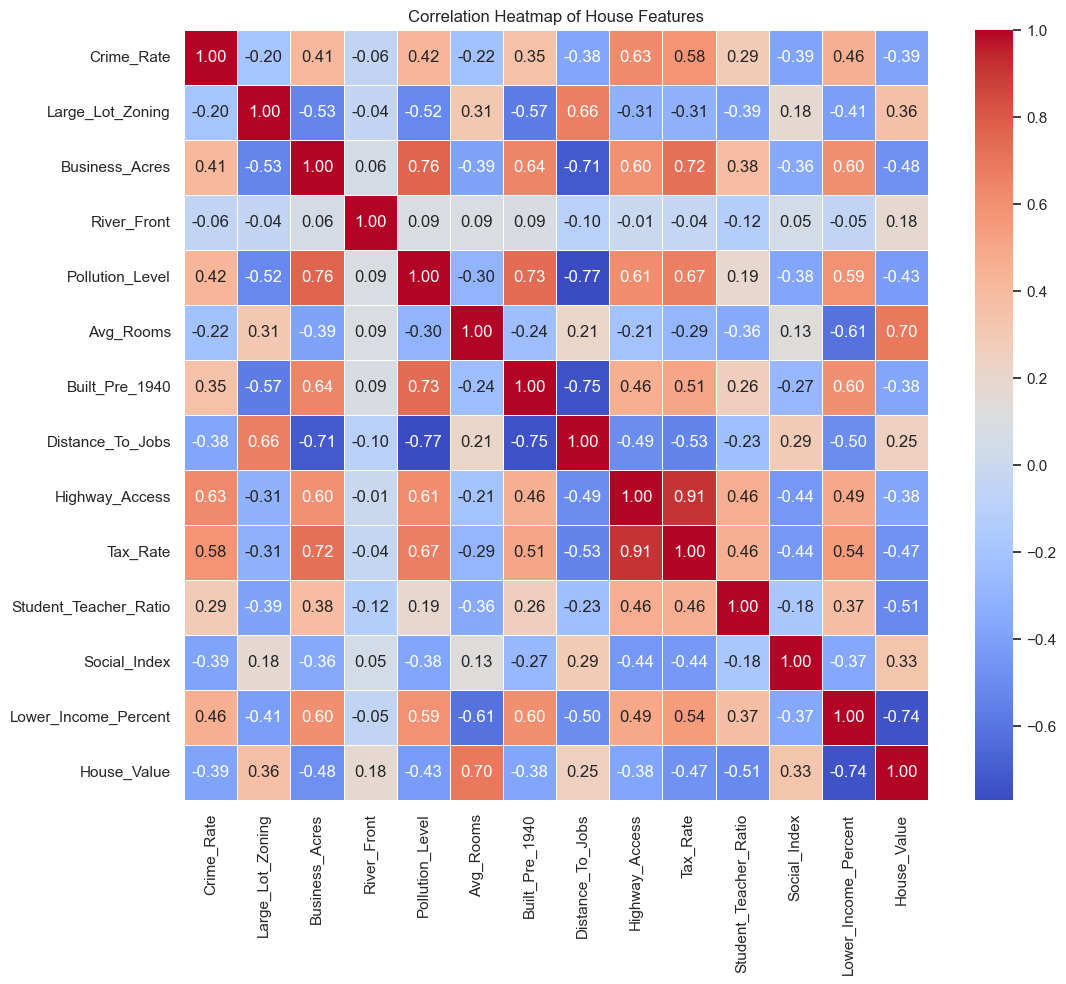

Crime_Rate               5.223149
Large_Lot_Zoning         2.225666
Business_Acres           0.295022
River_Front              3.405904
Pollution_Level          0.729308
Avg_Rooms                0.403612
Built_Pre_1940          -0.598963
Distance_To_Jobs         1.011781
Highway_Access           1.004815
Tax_Rate                 0.669956
Student_Teacher_Ratio   -0.802325
Social_Index            -2.890374
Lower_Income_Percent     0.906460
House_Value              1.108098
dtype: float64

In [6]:
# Step 6 – Correlation heatmap & skewness check
corr_matrix = df_before.corr()
plt.figure(figsize=(12, 10)) 

sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm', 
            fmt=".2f",      
            linewidths=0.5)  
plt.title('Correlation Heatmap of House Features')
plt.show()
df_before.skew()

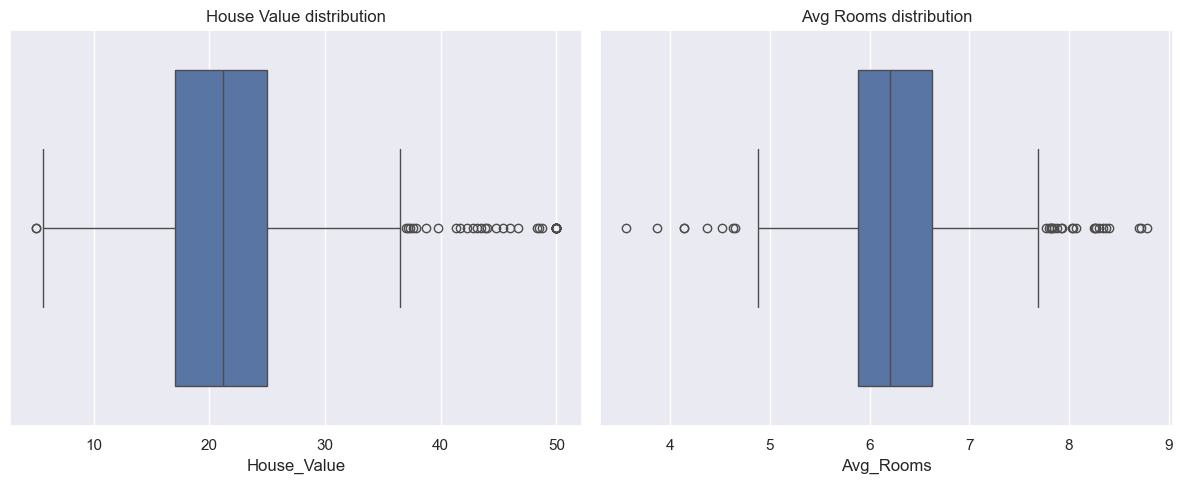

In [7]:
# Step 7 – Visualise distributions with boxplots to spot outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df_before['House_Value'], ax=axes[0])
axes[0].set_title('House Value distribution')
sns.boxplot(x=df_before['Avg_Rooms'], ax=axes[1])
axes[1].set_title('Avg Rooms distribution')

plt.tight_layout()
plt.show()

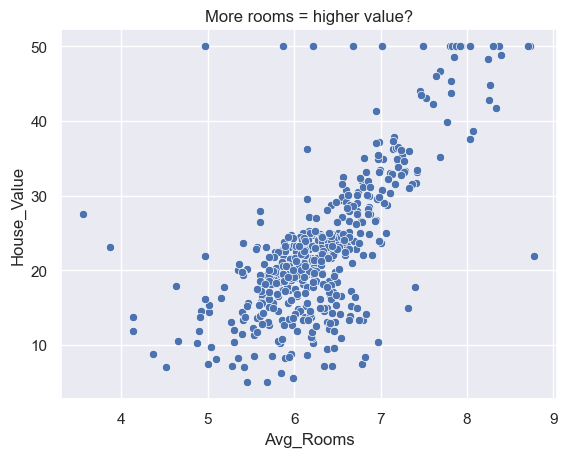

In [8]:
# Step 8 – Scatter plot: Avg Rooms vs House Value (before cleaning)
sns.scatterplot(x='Avg_Rooms', y='House_Value', data=df_before)
plt.title('More rooms = higher value?')
plt.show()

In [9]:
# Step 9 – Remove capped/suspicious House_Value entries (>= 50 are likely censored)

df = df_before.copy()
df = df[df['House_Value'] < 50].reset_index(drop=True)

## Putting a Cap for House Values

In [10]:
# Step 10 – IQR-based outlier removal for Avg_Rooms; clipping for Crime_Rate, Social_Index and House_Value
Q1_rooms = df['Avg_Rooms'].quantile(0.25)
Q3_rooms = df['Avg_Rooms'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms

lower_rooms = Q1_rooms - 1.5 * IQR_rooms
upper_rooms = Q3_rooms + 1.5 * IQR_rooms


df = df[(df['Avg_Rooms'] >= lower_rooms) & (df['Avg_Rooms'] <= upper_rooms)].copy()


df = df.reset_index(drop=True)

targets = ['Crime_Rate', 'Social_Index', 'House_Value']

for col in targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    low = Q1 - 1.5 * IQR
    up = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=low, upper=up)

print(f"Cleaning Done! Remaining rows: {len(df)}")

Cleaning Done! Remaining rows: 467


In [11]:
# Step 11 – Log-transform Crime_Rate to reduce right skew
df['Crime_Rate_log'] = np.log1p(df['Crime_Rate'])

## Dropping Outliers in Average Rooms

In [12]:
# Step 12 – Verify correlation after cleaning & check remaining skew
print(df['Avg_Rooms'].corr(df['House_Value']))
df.skew()

0.6445132106634658


Crime_Rate               1.282562
Large_Lot_Zoning         2.199757
Business_Acres           0.321213
River_Front              3.888128
Pollution_Level          0.772709
Avg_Rooms                0.127234
Built_Pre_1940          -0.570117
Distance_To_Jobs         0.985583
Highway_Access           1.055510
Tax_Rate                 0.700394
Student_Teacher_Ratio   -0.825617
Social_Index            -1.167460
Lower_Income_Percent     0.816242
House_Value              0.233268
Crime_Rate_log           0.937198
dtype: float64

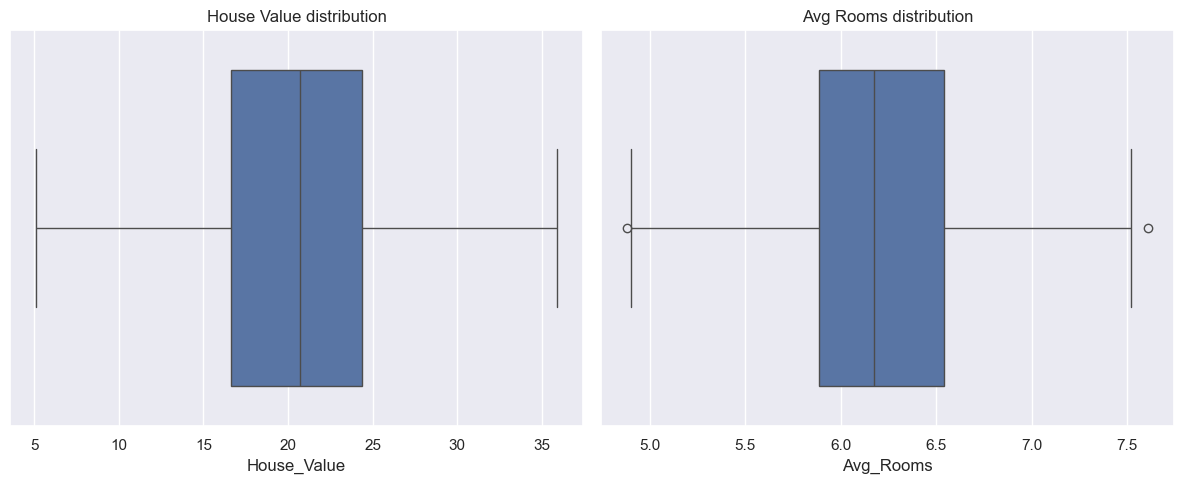

In [13]:
# Step 13 – Boxplots after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df['House_Value'], ax=axes[0])
axes[0].set_title('House Value distribution')
sns.boxplot(x=df['Avg_Rooms'], ax=axes[1])
axes[1].set_title('Avg Rooms distribution')
plt.tight_layout()
plt.show()

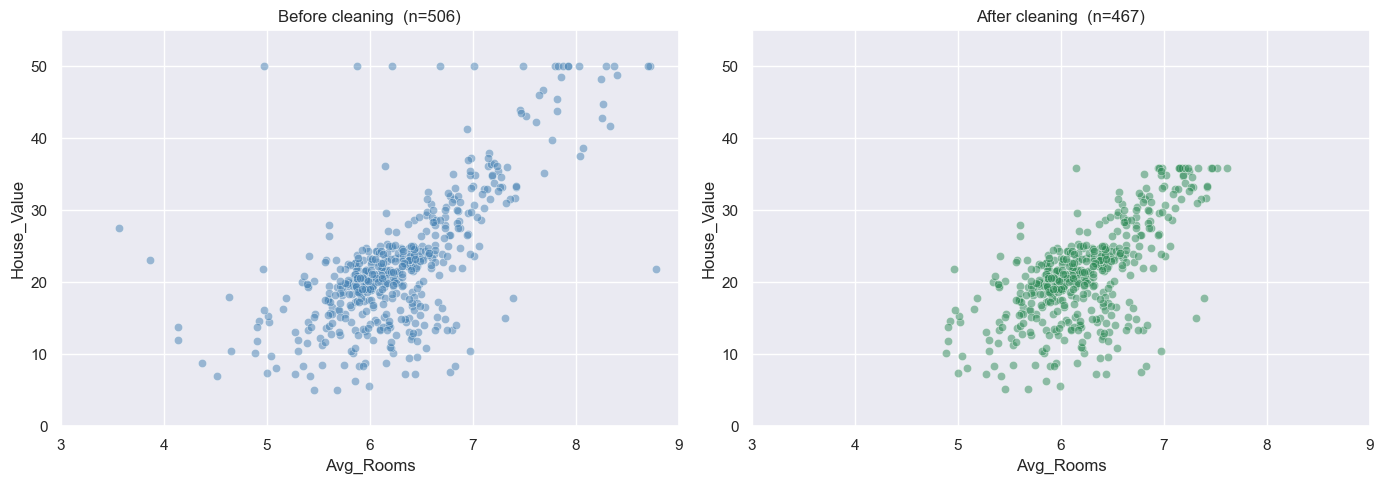

In [14]:
# Step 14 – Before vs After scatter comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Avg_Rooms', y='House_Value', data=df_before,
                ax=axes[0], alpha=0.5, color='steelblue')
axes[0].set_title(f'Before cleaning  (n={len(df_before)})')

sns.scatterplot(x='Avg_Rooms', y='House_Value', data=df,
                ax=axes[1], alpha=0.5, color='seagreen')
axes[1].set_title(f'After cleaning  (n={len(df)})')

axes[0].set_xlim(3, 9)
axes[1].set_xlim(3, 9)

axes[0].set_ylim(0, 55)
axes[1].set_ylim(0, 55)


plt.tight_layout()
plt.show()

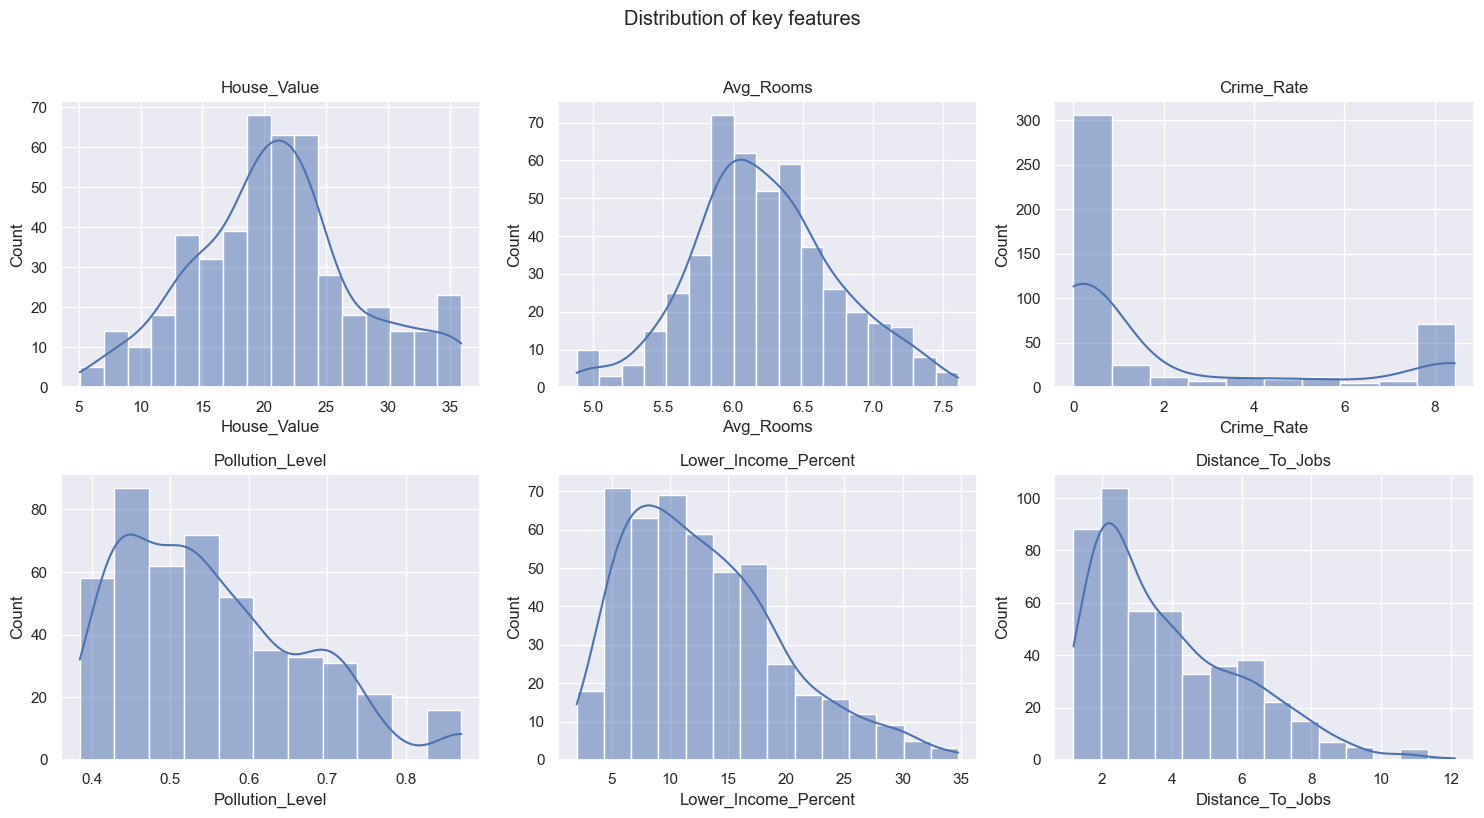

In [15]:
# Step 15 – Distribution histograms of key features after cleaning
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

columns = ['House_Value', 'Avg_Rooms', 'Crime_Rate',
           'Pollution_Level', 'Lower_Income_Percent', 'Distance_To_Jobs']

for i, col in enumerate(columns):
    row, col_idx = i // 3, i % 3
    sns.histplot(df[col], kde=True, ax=axes[row][col_idx])
    axes[row][col_idx].set_title(col)

plt.suptitle('Distribution of key features', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Step 16 – Save cleaned (pre-scaling) data to CSV
df.to_csv('cleaned_house_data.csv', index=False)

print("=== Ready for modelling ===")
print(f"Rows    : {len(df)}")
print(f"Columns : {df.columns.tolist()}")
print(f"Nulls   : {df.isnull().sum().sum()}")

=== Ready for modelling ===
Rows    : 467
Columns : ['Crime_Rate', 'Large_Lot_Zoning', 'Business_Acres', 'River_Front', 'Pollution_Level', 'Avg_Rooms', 'Built_Pre_1940', 'Distance_To_Jobs', 'Highway_Access', 'Tax_Rate', 'Student_Teacher_Ratio', 'Social_Index', 'Lower_Income_Percent', 'House_Value', 'Crime_Rate_log']
Nulls   : 0


In [17]:
# Step 17 – Standardize numerical features (zero mean, unit variance)
features_to_scale = [
    'Crime_Rate_log', 'Large_Lot_Zoning', 'Business_Acres', 'Pollution_Level',
    'Avg_Rooms', 'Built_Pre_1940', 'Distance_To_Jobs', 'Highway_Access',
    'Tax_Rate', 'Student_Teacher_Ratio', 'Social_Index', 'Lower_Income_Percent'
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Standardization complete. Sample of scaled features:")
df_scaled[features_to_scale].describe().round(3)

Standardization complete. Sample of scaled features:


,Crime_Rate_log,Large_Lot_Zoning,Business_Acres,Pollution_Level,Avg_Rooms,Built_Pre_1940,Distance_To_Jobs,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Social_Index,Lower_Income_Percent
count,467.000,467.000,467.000,467.000,467.000,467.000,467.000,467.000,467.000,467.000,467.000,467.000
mean,-0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.839,-0.490,-1.531,-1.445,-2.596,-2.313,-1.275,-0.969,-1.324,-2.818,-1.969,-1.637
25%,-0.754,-0.490,-0.878,-0.898,-0.650,-0.870,-0.827,-0.621,-0.759,-0.540,-0.331,-0.800
50%,-0.602,-0.490,-0.217,-0.138,-0.093,0.308,-0.262,-0.505,-0.464,0.267,0.516,-0.147
75%,0.920,0.055,1.017,0.597,0.620,0.917,0.669,1.698,1.556,0.789,0.761,0.618
max,1.820,3.870,2.431,2.708,2.684,1.135,3.901,1.698,1.827,1.643,0.774,3.248


In [18]:
# Step 18 – Save final scaled dataset
df_scaled.to_csv('cleaned_scaled_house_data.csv', index=False)
print(f"Final dataset saved: {df_scaled.shape[0]} rows x {df_scaled.shape[1]} columns")
print("\n Task 2 – Data Cleaning & Preprocessing complete!")
df_scaled.head()

Final dataset saved: 467 rows x 15 columns

 Task 2 – Data Cleaning & Preprocessing complete!


,Crime_Rate,Large_Lot_Zoning,Business_Acres,River_Front,Pollution_Level,Avg_Rooms,Built_Pre_1940,Distance_To_Jobs,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Social_Index,Lower_Income_Percent,House_Value,Crime_Rate_log
0,0.00632,0.294864,-1.300202,0,-0.137838,0.682497,-0.100787,0.103089,-0.969125,-0.668899,-1.536402,0.773851,-1.190078,24.0,-0.839189
1,0.02731,-0.490009,-0.601805,0,-0.727473,0.384635,0.385691,0.517593,-0.853168,-0.993651,-0.349981,0.773851,-0.570282,21.6,-0.814677
2,0.02729,-0.490009,-0.601805,0,-0.727473,1.862341,-0.246376,0.517593,-0.853168,-0.993651,-0.349981,0.557914,-1.331618,34.7,-0.814700
3,0.03237,-0.490009,-1.319275,0,-0.821472,1.500651,-0.789669,1.035119,-0.737210,-1.113930,0.077130,0.653414,-1.494016,33.4,-0.808843
4,0.06905,-0.490009,-1.319275,0,-0.821472,1.788843,-0.491391,1.035119,-0.737210,-1.113930,0.077130,0.773851,-1.137931,35.9,-0.767387


## Level 2 – Task 1:  Predictive Modeling (Regression)

In [19]:
#step 1 checking multicolinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = df_scaled[[
    'Crime_Rate_log', 'Large_Lot_Zoning', 'Business_Acres', 'Pollution_Level',
    'Avg_Rooms', 'Built_Pre_1940', 'Distance_To_Jobs', 'Highway_Access',
    'Tax_Rate', 'Student_Teacher_Ratio', 'Social_Index', 'Lower_Income_Percent'
]]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["features"] = variables.columns
vif

,VIF,features
0,14.471879,Crime_Rate_log
1,2.418887,Large_Lot_Zoning
2,3.915070,Business_Acres
3,4.996600,Pollution_Level
4,1.948212,Avg_Rooms
5,3.179199,Built_Pre_1940
6,4.035126,Distance_To_Jobs
7,14.557876,Highway_Access
8,8.257117,Tax_Rate
9,1.688820,Student_Teacher_Ratio


In [20]:
#step 2 drop high VIF predictors
df_scaled = df_scaled.drop(columns=['Crime_Rate_log', 'Highway_Access'])

In [21]:
#step 3 train test split
y= df_scaled["House_Value"]
x = df_scaled[["Avg_Rooms"]]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=365)

In [22]:
#step 4 linear regression
reg = LinearRegression()
reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Intercept  : 21.0110
Coefficient (Avg_Rooms): 4.4602
Interpretation: for every 1 unit increase in Avg_Rooms, House_Value changes by 4.4602


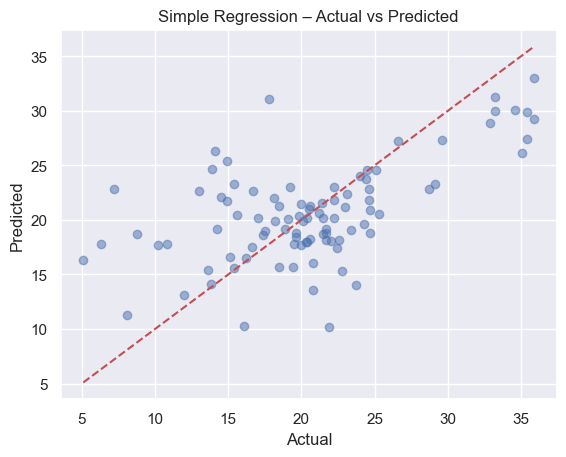

In [23]:
#step 5 predict and visualize – actual vs predicted
y_hat = reg.predict(x_test)

# print what the model learned
print(f"Intercept  : {reg.intercept_:.4f}")
print(f"Coefficient (Avg_Rooms): {reg.coef_[0]:.4f}")
print("Interpretation: for every 1 unit increase in Avg_Rooms, House_Value changes by", round(reg.coef_[0], 4))

plt.scatter(y_test, y_hat, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Simple Regression – Actual vs Predicted')
plt.show()

In [24]:
#step 6 evaluate simple regression
mae  = mean_absolute_error(y_test, y_hat)
mse  = mean_squared_error(y_test, y_hat)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_hat)
print("Simple Linear Regression Metrics")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Simple Linear Regression Metrics
MAE  : 4.03
MSE  : 28.80
RMSE : 5.37
R²   : 0.3388


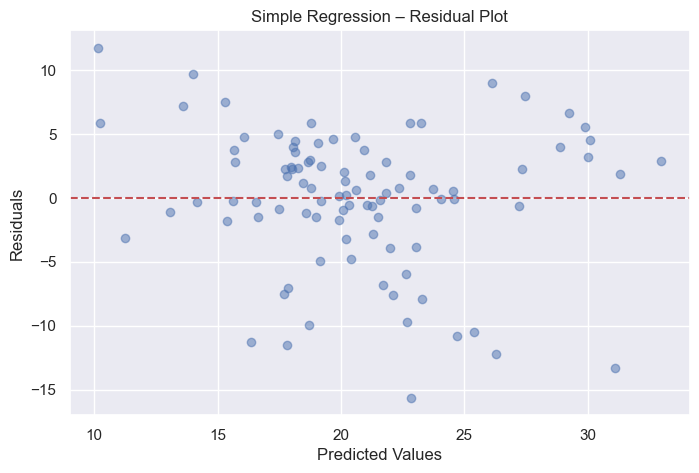

In [25]:
#step 7 residual plot . simple regression
residuals = y_test - y_hat

plt.figure(figsize=(8,5))
plt.scatter(y_hat, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Simple Regression – Residual Plot')
plt.show()

## Multiple Linear Regression

In [26]:
#step 8 define X with all 10 post VIF features and split
x_multi = df_scaled[[
    'Large_Lot_Zoning', 'Business_Acres', 'Pollution_Level',
    'Avg_Rooms', 'Built_Pre_1940', 'Distance_To_Jobs',
    'Tax_Rate', 'Student_Teacher_Ratio', 'Social_Index', 'Lower_Income_Percent'
]]
y_multi = df_scaled['House_Value']

x_train_m, x_test_m, y_train_m, y_test_m = train_test_split(x_multi, y_multi, test_size=0.2, random_state=365)

In [27]:
#step 9 train multiple linear regression
reg_multi = LinearRegression()
reg_multi.fit(x_train_m, y_train_m)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
#step 10 print all coefficients shows each feature's impact on House_Value
print(f"Intercept: {reg_multi.intercept_:.4f}")

coef_df = pd.DataFrame({
    'Feature': x_train_m.columns,
    'Coefficient': reg_multi.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

Intercept: 21.0306
              Feature  Coefficient
            Avg_Rooms     1.934081
     Large_Lot_Zoning     0.398586
         Social_Index     0.350874
       Business_Acres    -0.153749
       Built_Pre_1940    -0.634506
      Pollution_Level    -0.904089
             Tax_Rate    -1.198749
Student_Teacher_Ratio    -1.488168
     Distance_To_Jobs    -1.798308
 Lower_Income_Percent    -2.503200


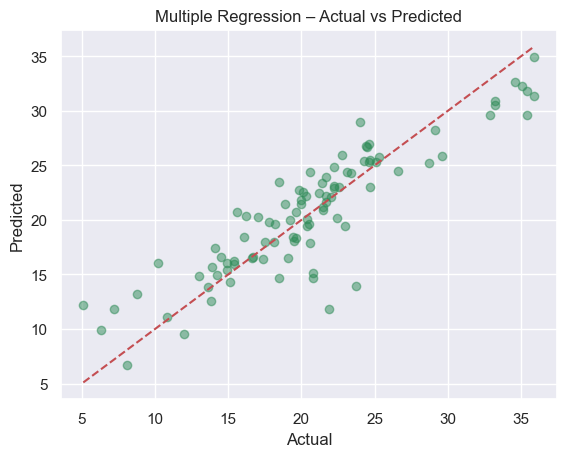

In [29]:
#step 11 predict and visualize – actual vs predicted
y_hat_m = reg_multi.predict(x_test_m)

plt.scatter(y_test_m, y_hat_m, alpha=0.5, color='seagreen')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Multiple Regression – Actual vs Predicted')
plt.show()

In [30]:
#step 12 evaluate multiple regression
mae_m  = mean_absolute_error(y_test_m, y_hat_m)
mse_m  = mean_squared_error(y_test_m, y_hat_m)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test_m, y_hat_m)
print("Multiple Linear Regression Metrics")
print(f"MAE  : {mae_m:.2f}")
print(f"MSE  : {mse_m:.2f}")
print(f"RMSE : {rmse_m:.2f}")
print(f"R²   : {r2_m:.4f}")

Multiple Linear Regression Metrics
MAE  : 2.27
MSE  : 8.99
RMSE : 3.00
R²   : 0.7937


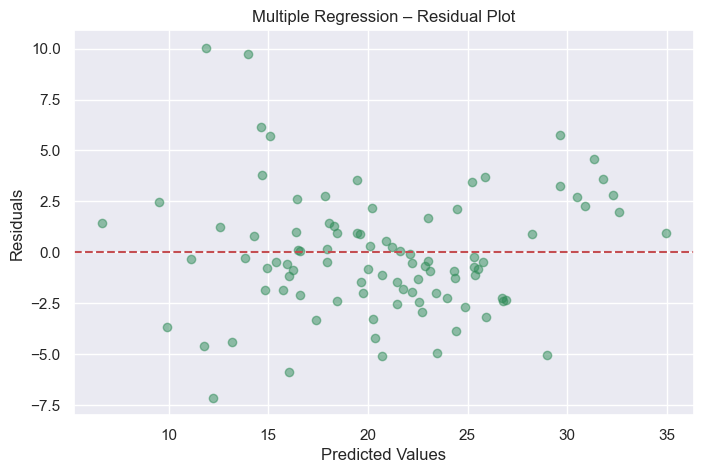

In [31]:
#step 13 residual plot – multiple regression
residuals_m = y_test_m - y_hat_m

plt.figure(figsize=(8,5))
plt.scatter(y_hat_m, residuals_m, alpha=0.5, color='seagreen')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Multiple Regression – Residual Plot')
plt.show()

In [32]:
#step 14 comparison table – simple vs multiple regression
comparison = pd.DataFrame({
    'Model' : ['Simple Regression (Avg_Rooms only)', 'Multiple Regression (10 features)'],
    'MAE' : [mae, mae_m],
    'MSE'  : [mse, mse_m],
    'RMSE': [rmse, rmse_m],
    'R²' : [r2,  r2_m]
})
comparison.round(4)

,Model,MAE,MSE,RMSE,R²
0,Simple Regression (Avg_Rooms only),4.0279,28.7996,5.3665,0.3388
1,Multiple Regression (10 features),2.2723,8.9859,2.9977,0.7937


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=365)
rf.fit(x_train_m, y_train_m)
y_hat_rf = rf.predict(x_test_m)

In [34]:
mae_rf  = mean_absolute_error(y_test_m, y_hat_rf)
mse_rf  = mean_squared_error(y_test_m, y_hat_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test_m, y_hat_rf)

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=365)
dt.fit(x_train_m, y_train_m)
y_hat_dt = dt.predict(x_test_m)

In [37]:
mae_dt  = mean_absolute_error(y_test_m, y_hat_dt)
mse_dt  = mean_squared_error(y_test_m, y_hat_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt   = r2_score(y_test_m, y_hat_dt)

In [38]:
comparison = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE'    : [mae_m,  mae_dt,  mae_rf],
    'MSE'    : [mse_m,  mse_dt,  mse_rf],
    'RMSE'   : [rmse_m, rmse_dt, rmse_rf],
    'R²'     : [r2_m,   r2_dt,   r2_rf]
})
comparison.round(4)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,2.2723,8.9859,2.9977,0.7937
1,Decision Tree,2.9851,16.0462,4.0058,0.6316
2,Random Forest,1.7778,5.4530,2.3352,0.8748


## Conclusion

Simple linear regression using only Avg_Rooms achieved an R² of 0.34, meaning the model explains roughly 33% of the variance in house prices. This is expected — a single feature cannot capture the full complexity of housing prices.

Multiple linear regression using all 10 post-VIF features significantly improved performance to R² 0.79, demonstrating that combining neighborhood, economic, and structural features together gives the model a much more complete picture of what drives house values.

To push performance further, two additional models were tested. Decision Tree regression underperformed at R² 0.63  worse than even linear regression — which is a classic sign of overfitting. The model memorized training patterns too closely and failed to generalize to unseen data.

Random Forest regression delivered the best results with R² 0.87, MAE of 1.78, and RMSE of 2.35. By averaging predictions across 100 decision trees, each trained on random subsets of the data, the ensemble approach cancels out individual errors and handles non-linear relationships that linear regression cannot capture.

**Level 2 – Task 1: Predictive Modeling (Regression) complete**